In [3]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_excel("C:/Desktop/GROWFINIX-Internship-Tasks/TASK 5/Healthcare_Data.xlsx")

In [11]:
df

,Patient ID,Admission Date,Department,Length of Stay,Gender,Age
0,P001,2025-01-05,Cardiology,5,Male,45
1,P002,2025-01-10,Neurology,8,Female,52
2,P003,2025-02-12,Orthopedics,4,Male,33
3,P004,2025-02-18,Pediatrics,3,Female,12
4,P005,2025-03-08,Cardiology,6,Male,61
5,P006,2025-03-20,Neurology,9,Female,48
6,P007,2025-04-02,Orthopedics,7,Male,39
7,P008,2025-04-15,Pediatrics,2,Female,8
8,P009,2025-05-06,Cardiology,10,Male,58
9,P010,2025-05-18,Neurology,6,Female,46


In [13]:
df.head()

,Patient ID,Admission Date,Department,Length of Stay,Gender,Age
0,P001,2025-01-05,Cardiology,5,Male,45
1,P002,2025-01-10,Neurology,8,Female,52
2,P003,2025-02-12,Orthopedics,4,Male,33
3,P004,2025-02-18,Pediatrics,3,Female,12
4,P005,2025-03-08,Cardiology,6,Male,61


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Patient ID      20 non-null     str           
 1   Admission Date  20 non-null     datetime64[us]
 2   Department      20 non-null     str           
 3   Length of Stay  20 non-null     int64         
 4   Gender          20 non-null     str           
 5   Age             20 non-null     int64         
dtypes: datetime64[us](1), int64(2), str(3)
memory usage: 1.1 KB


In [17]:
df.isnull().sum()

Patient ID        0
Admission Date    0
Department        0
Length of Stay    0
Gender            0
Age               0
dtype: int64

In [19]:
df = df.dropna()

In [21]:
df["Admission Date"] = pd.to_datetime(df["Admission Date"])

In [23]:
df

,Patient ID,Admission Date,Department,Length of Stay,Gender,Age
0,P001,2025-01-05,Cardiology,5,Male,45
1,P002,2025-01-10,Neurology,8,Female,52
2,P003,2025-02-12,Orthopedics,4,Male,33
3,P004,2025-02-18,Pediatrics,3,Female,12
4,P005,2025-03-08,Cardiology,6,Male,61
5,P006,2025-03-20,Neurology,9,Female,48
6,P007,2025-04-02,Orthopedics,7,Male,39
7,P008,2025-04-15,Pediatrics,2,Female,8
8,P009,2025-05-06,Cardiology,10,Male,58
9,P010,2025-05-18,Neurology,6,Female,46


In [25]:
df["Month"] = df["Admission Date"].dt.month_name()
df

,Patient ID,Admission Date,Department,Length of Stay,Gender,Age,Month
0,P001,2025-01-05,Cardiology,5,Male,45,January
1,P002,2025-01-10,Neurology,8,Female,52,January
2,P003,2025-02-12,Orthopedics,4,Male,33,February
3,P004,2025-02-18,Pediatrics,3,Female,12,February
4,P005,2025-03-08,Cardiology,6,Male,61,March
5,P006,2025-03-20,Neurology,9,Female,48,March
6,P007,2025-04-02,Orthopedics,7,Male,39,April
7,P008,2025-04-15,Pediatrics,2,Female,8,April
8,P009,2025-05-06,Cardiology,10,Male,58,May
9,P010,2025-05-18,Neurology,6,Female,46,May


In [27]:
monthly = df.groupby("Month").size()
print(monthly)


Month
April        2
August       1
December     2
February     2
January      2
July         1
June         2
March        2
May          2
November     2
October      1
September    1
dtype: int64


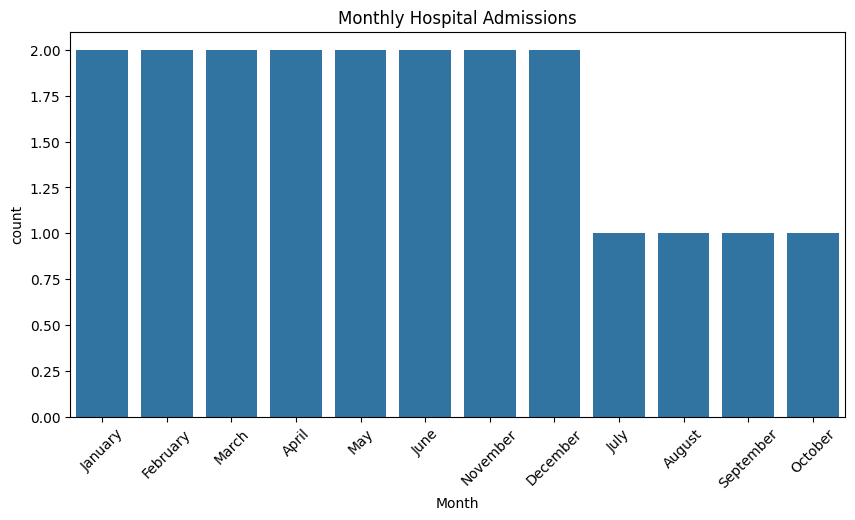

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Month", order=df["Month"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Monthly Hospital Admissions")
plt.show()

In [31]:
avg = df.groupby("Department")["Length of Stay"].mean()

print(avg)

Department
Cardiology     12.8
Neurology       7.2
Orthopedics     6.6
Pediatrics      3.2
Name: Length of Stay, dtype: float64


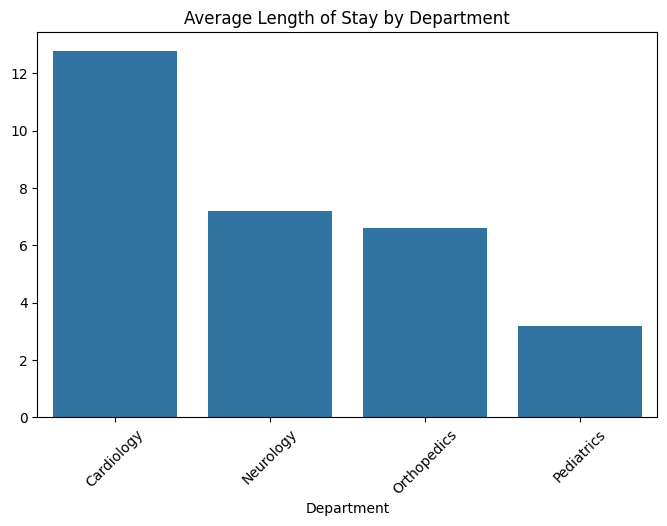

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x=avg.index, y=avg.values)
plt.title("Average Length of Stay by Department")
plt.xticks(rotation=45)
plt.show()

In [35]:
Q1 = df["Length of Stay"].quantile(0.25)
Q3 = df["Length of Stay"].quantile(0.75)
IQR = Q3 - Q1

In [37]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [39]:
df_clean = df[(df["Length of Stay"] >= lower) &
              (df["Length of Stay"] <= upper)]

In [41]:
print(df_clean.shape)

(19, 7)


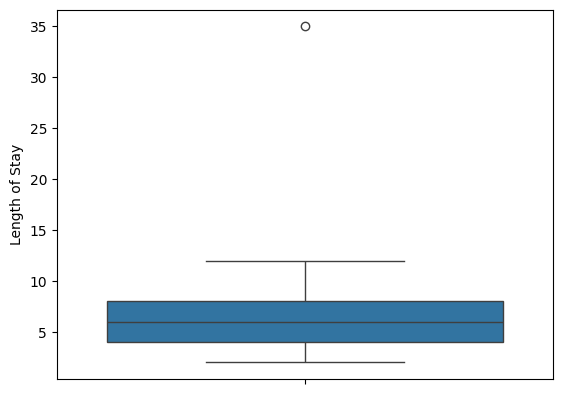

In [43]:
sns.boxplot(y=df["Length of Stay"])
plt.show()

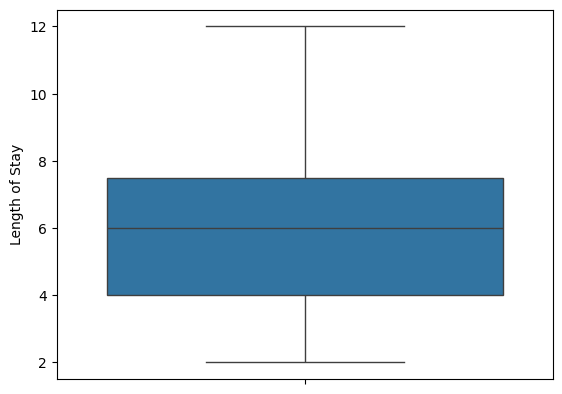

In [45]:
sns.boxplot(y=df_clean["Length of Stay"])
plt.show()

In [47]:
df_clean.to_csv("Healthcare_Cleaned.csv", index=False)